In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import rowcol
import pickle
import psutil
import gc

# get transform from DEM
with rasterio.open('../data/Canwell_FullDomain_DEM3m.tif') as src:
    transform = src.transform
    crs = src.crs

print(f"Transform: {transform}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

Transform: | 3.00, 0.00, 566213.75|
| 0.00,-3.00, 7028444.75|
| 0.00, 0.00, 1.00|
RAM: 6.0%


In [5]:
from rasterio.transform import rowcol
row, col = rowcol(transform, 570659.35, 7025885.78)
print(f"Row: {row}, Col: {col}")

Row: 852, Col: 1481


In [8]:

# ── USER: adjust these to center on an interesting feature ──
CENTER_ROW = 850  # adjust after seeing the plot
CENTER_COL = 1500  # adjust after seeing the plot
WINDOW = 100       # half-width in pixels (100 = 300m at 3m res)
# ────────────────────────────────────────────────────────────

# load DEM for hillshade
with rasterio.open('../data/Canwell_FullDomain_DEM3m.tif') as src:
    dem = src.read(1).astype(np.float32)
    dem[dem == src.nodata] = np.nan

# compute hillshade
def hillshade(dem, azimuth=315, altitude=45):
    az = np.deg2rad(azimuth)
    alt = np.deg2rad(altitude)
    dy, dx = np.gradient(dem, 3.0)  # 3m cell size
    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(-dy, dx)
    hs = (np.sin(alt) * np.cos(slope) +
          np.cos(alt) * np.sin(slope) * np.cos(az - aspect))
    return np.clip(hs, 0, 1)

hs = hillshade(dem)

# crop window
r0, r1 = CENTER_ROW - WINDOW, CENTER_ROW + WINDOW
c0, c1 = CENTER_COL - WINDOW, CENTER_COL + WINDOW
hs_crop = hs[r0:r1, c0:c1]
dem_crop = dem[r0:r1, c0:c1]
print("done")

done


In [10]:
# extract nodes in window
with open('../data/canwell_graph.pkl', 'rb') as f:
    gdata = pickle.load(f)
G = gdata['G']

node_rows, node_cols, node_ids, node_elevs = [], [], [], []
for nid, attr in G.nodes(data=True):
    r, c = attr['dem_idx']
    if r0 <= r < r1 and c0 <= c < c1:
        node_rows.append(r - r0)
        node_cols.append(c - c0)
        node_ids.append(nid)
        node_elevs.append(attr['elev'])

print(f"Nodes in window: {len(node_ids):,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

# extract edges where both endpoints in window
node_set = set(node_ids)
edge_pairs = []
edge_weights = []
for u, v, attr in G.edges(data=True):
    if u in node_set and v in node_set:
        ru, cu = G.nodes[u]['dem_idx']
        rv, cv = G.nodes[v]['dem_idx']
        edge_pairs.append(((cu-c0, ru-r0), (cv-c0, rv-r0)))
        edge_weights.append(attr['weight'])

print(f"Edges in window: {len(edge_pairs):,}")

del G, gdata
import gc
gc.collect()
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

Nodes in window: 40,000
RAM: 97.4%
Edges in window: 158,802
RAM: 27.6%


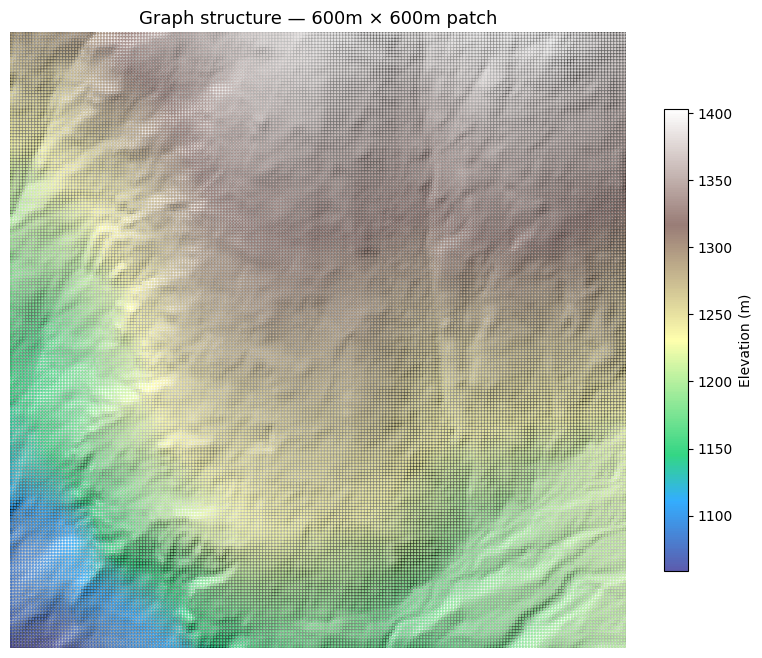

In [11]:
# plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(hs_crop, cmap='gray', origin='upper', vmin=0, vmax=1)

# draw edges colored by slope weight
norm = mcolors.Normalize(vmin=np.percentile(edge_weights, 5),
                          vmax=np.percentile(edge_weights, 95))
cmap = plt.cm.plasma

for (c1e, r1e), (c2e, r2e) in edge_pairs:
    ax.plot([c1e, c2e], [r1e, r2e], 'w-', alpha=0.15, linewidth=0.4)

# draw nodes colored by elevation
sc = ax.scatter(node_cols, node_rows, c=node_elevs,
                cmap='terrain', s=4, alpha=0.8, linewidths=0)

plt.colorbar(sc, ax=ax, label='Elevation (m)', shrink=0.6)
ax.set_title(f'Graph structure — {WINDOW*2*3}m × {WINDOW*2*3}m patch', fontsize=13)
ax.set_xlabel('Column (3m pixels)')
ax.set_ylabel('Row (3m pixels)')
ax.axis('off')

plt.tight_layout()
#plt.savefig('canwell_graph_viz.png', dpi=200, bbox_inches='tight')
plt.show()
#print("Saved!")

In [12]:
# try again, export as JSON

In [ ]:
from rasterio.transform import xy
import json


In [37]:
# use your chosen center point
CENTER_ROW, CENTER_COL = 852, 1481  # plug in your converted values
WINDOW = 4 # 4 pixels = 12m radius, ~50 nodes in 8x8 patch

In [38]:
r0, r1 = CENTER_ROW - WINDOW, CENTER_ROW + WINDOW
c0, c1 = CENTER_COL - WINDOW, CENTER_COL + WINDOW

In [3]:
# reload graph
with open('../data/canwell_graph.pkl', 'rb') as f:
    gdata = pickle.load(f)
G = gdata['G']

In [4]:
print(f"G loaded. RAM: {psutil.virtual_memory().percent:.1f}%")

G loaded. RAM: 80.1%


In [8]:
# check what dem_idx values actually look like in the graph
sample_nodes = list(G.nodes(data=True))[:5]
for nid, attr in sample_nodes:
    print(attr['dem_idx'])

(0, 125)
(0, 126)
(0, 127)
(0, 128)
(0, 129)


In [10]:
# find actual extent of valid nodes
rows = [attr['dem_idx'][0] for _, attr in G.nodes(data=True)]
cols = [attr['dem_idx'][1] for _, attr in G.nodes(data=True)]
print(f"Row range: {min(rows)} - {max(rows)}")
print(f"Col range: {min(cols)} - {max(cols)}")
print(f"Shape: {gdata['shape']}")

Row range: 0 - 2573
Col range: 0 - 4515
Shape: (2574, 4516)


In [14]:
# check one node's dem_idx type
nid, attr = list(G.nodes(data=True))[100]
print(type(attr['dem_idx']))
print(attr['dem_idx'])
print(type(attr['dem_idx'][0]))

# manual check
r, c = attr['dem_idx']
print(f"r={r}, c={c}")
print(f"r0={852-4}, r1={852+4}, c0={1481-4}, c1={1481+4}")
print(f"In window: {852-4 <= r < 852+4 and 1481-4 <= c < 1481+4}")

<class 'tuple'>
(0, 225)
<class 'int'>
r=0, c=225
r0=848, r1=856, c0=1477, c1=1485
In window: False


In [15]:
# find closest node to target
target_r, target_c = 852, 1481
min_dist = float('inf')
closest = None

for nid, attr in G.nodes(data=True):
    r, c = attr['dem_idx']
    dist = (r - target_r)**2 + (c - target_c)**2
    if dist < min_dist:
        min_dist = dist
        closest = (r, c)

print(f"Closest node: {closest}")
print(f"Distance: {min_dist**0.5:.1f} pixels")

Closest node: (852, 1481)
Distance: 0.0 pixels


In [39]:
# extract nodes in window
nodes_in_window = {}
features = []
for nid, attr in G.nodes(data=True):
    r, c = attr['dem_idx']
    if r0 <= r < r1 and c0 <= c < c1:
        x_coord, y_coord = xy(transform, r, c)
        nodes_in_window[nid] = (x_coord, y_coord)
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [x_coord, y_coord]},
            "properties": {"elev": float(attr['elev']), "slope": float(attr['slope'] or 0)}
        })

print(f"Nodes: {len(nodes_in_window)}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

Nodes: 64
RAM: 80.8%


In [40]:
# export nodes
node_geojson = {"type": "FeatureCollection", "features": features}
with open('canwell_graph_nodes.geojson', 'w') as f:
    json.dump(node_geojson, f)
print("nodes saved")

# extract and export edges
edge_features = []
node_set = set(nodes_in_window.keys())
for u, v, attr in G.edges(data=True):
    if u in node_set and v in node_set:
        x1, y1 = nodes_in_window[u]
        x2, y2 = nodes_in_window[v]
        edge_features.append({
            "type": "Feature",
            "geometry": {"type": "LineString", "coordinates": [[x1, y1], [x2, y2]]},
            "properties": {"weight": float(attr['weight'])}
        })

print(f"Edges: {len(edge_features)}")

edge_geojson = {"type": "FeatureCollection", "features": edge_features}
with open('canwell_graph_edges.geojson', 'w') as f:
    json.dump(edge_geojson, f)
print("edges saved")

nodes saved
Edges: 210
edges saved


In [41]:
with open('canwell_graph_nodes.json', 'w') as f:
    json.dump(node_geojson, f)

with open('canwell_graph_edges.json', 'w') as f:
    json.dump(edge_geojson, f)

print("jsons saved")

jsons saved


In [42]:
import geopandas as gpd

# nodes
nodes_gdf = gpd.GeoDataFrame.from_features(node_geojson['features'], crs='EPSG:32606')
nodes_gdf.to_file('canwell_graph_nodes.shp')

# edges  
edges_gdf = gpd.GeoDataFrame.from_features(edge_geojson['features'], crs='EPSG:32606')
edges_gdf.to_file('canwell_graph_edges.shp')

print("Saved as shapefiles!")

Saved as shapefiles!


In [ ]:
del G, gdata
gc.collect()
print(f"Saved! RAM: {psutil.virtual_memory().percent:.1f}%")